In [85]:
# Import required libraries 
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style('whitegrid')
# statsmodels is the standard library for detailed regression analysis in Python
import statsmodels.api as sm

%matplotlib inline

In [86]:
# Now we are going to load the auto mpg dataset
df = pd.read_csv('./data/auto-mpg.csv')
df.head()

,mpg,cylinders,displacement,horsepower,weight,acceleration,model year,origin,car name
0,18.0,8,307.0,130,3504,12.0,70,1,chevrolet chevelle malibu
1,15.0,8,350.0,165,3693,11.5,70,1,buick skylark 320
2,18.0,8,318.0,150,3436,11.0,70,1,plymouth satellite
3,16.0,8,304.0,150,3433,12.0,70,1,amc rebel sst
4,17.0,8,302.0,140,3449,10.5,70,1,ford torino


In [87]:
# View summary of the dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 398 entries, 0 to 397
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   mpg           398 non-null    float64
 1   cylinders     398 non-null    int64  
 2   displacement  398 non-null    float64
 3   horsepower    398 non-null    object 
 4   weight        398 non-null    int64  
 5   acceleration  398 non-null    float64
 6   model year    398 non-null    int64  
 7   origin        398 non-null    int64  
 8   car name      398 non-null    object 
dtypes: float64(3), int64(4), object(2)
memory usage: 28.1+ KB


After checking the unique values, we found that there is one unique value ('?') which was hidden when I checked the missing value, so now i am going to handle it.

In [88]:
# Replace ? with NaN 
df['horsepower'] = df['horsepower'].replace('?',np.nan)

In [89]:
df['horsepower'] = pd.to_numeric(df['horsepower'],errors="coerce")

In [90]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 398 entries, 0 to 397
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   mpg           398 non-null    float64
 1   cylinders     398 non-null    int64  
 2   displacement  398 non-null    float64
 3   horsepower    392 non-null    float64
 4   weight        398 non-null    int64  
 5   acceleration  398 non-null    float64
 6   model year    398 non-null    int64  
 7   origin        398 non-null    int64  
 8   car name      398 non-null    object 
dtypes: float64(4), int64(4), object(1)
memory usage: 28.1+ KB


In [91]:
# drop rows any missing value in any columns
df.dropna(inplace=True)

In [92]:
df.shape

(392, 9)

## Visualization

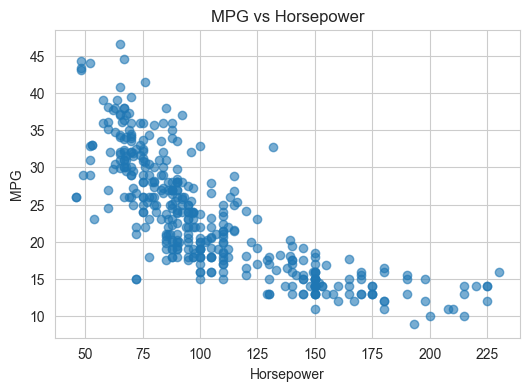

In [93]:
# Visualise a scatter plot between MPG vs Horsepower
plt.figure(figsize=(6,4))
plt.scatter(df['horsepower'],df['mpg'],alpha=0.6)
plt.xlabel('Horsepower')
plt.ylabel('MPG')
plt.title('MPG vs Horsepower')
plt.show()

**Curvature**

Notice how there is a bit of a curve, if you were to draw a "best fit" line?

To get non-straight lines we'll need to introduce polynomial terms.

In [94]:
# using the OLS method that is like an equation mpg ~ horsepower
X = df['horsepower']
Y = df['mpg']
# Add a constant to the independent variable, this is required for statsmodels to calculate the intercept
X_with_const = sm.add_constant(X)
model_hp = sm.OLS(Y,X_with_const).fit()
print(model_hp.summary())



                            OLS Regression Results                            
Dep. Variable:                    mpg   R-squared:                       0.606
Model:                            OLS   Adj. R-squared:                  0.605
Method:                 Least Squares   F-statistic:                     599.7
Date:                Wed, 18 Mar 2026   Prob (F-statistic):           7.03e-81
Time:                        11:43:20   Log-Likelihood:                -1178.7
No. Observations:                 392   AIC:                             2361.
Df Residuals:                     390   BIC:                             2369.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         39.9359      0.717     55.660      0.0

## Linear Regression Modelling with MPG as Target Var. & horsepower^2 as Predictor Variable

In [95]:
# create an X with horsepower and horsepower squared to capture non-linear relationship
X = df['horsepower']
X_squared = X**2
X = pd.DataFrame({'horsepower': X, 'horsepower_squared': X_squared})
Y = df['mpg']

X.head()



,horsepower,horsepower_squared
0,130.0,16900.0
1,165.0,27225.0
2,150.0,22500.0
3,150.0,22500.0
4,140.0,19600.0


In [96]:
# Add a constant to the independent variable, this is required for statsmodels to calculate the intercept
X_with_const = sm.add_constant(X)

model_weight= sm.OLS(Y,X_with_const).fit()

print(model_weight.summary())

                            OLS Regression Results                            
Dep. Variable:                    mpg   R-squared:                       0.688
Model:                            OLS   Adj. R-squared:                  0.686
Method:                 Least Squares   F-statistic:                     428.0
Date:                Wed, 18 Mar 2026   Prob (F-statistic):           5.40e-99
Time:                        11:43:20   Log-Likelihood:                -1133.2
No. Observations:                 392   AIC:                             2272.
Df Residuals:                     389   BIC:                             2284.
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                         coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------
const                 56.9001      1

### Assessing the quadratic model and interpreting the coefficients

The quadratic regression model is:

$$
\widehat{mpg} = 56.9001 - 0.4662(\text{horsepower}) + 0.001231(\text{horsepower}^2)
$$

Model fit:

- $R^2 = 0.6876$
- Adjusted $R^2 = 0.6860$
- F-statistic $= 428.0176$
- Prob(F-statistic) $= 5.40 \times 10^{-99}$

Coefficient output from the quadratic model:

- Intercept: coef $= 56.9001$, std err $= 1.8004$, $t = 31.6037$, $p < 0.001$
- Horsepower: coef $= -0.4662$, std err $= 0.0311$, $t = -14.9782$, $p < 0.001$
- Horsepower squared: coef $= 0.001231$, std err $= 0.000122$, $t = 10.0801$, $p < 0.001$

Interpretation:

- The model explains about **68.8%** of the variation in MPG.
- Both the linear and squared horsepower terms are statistically significant, so the relationship between horsepower and MPG is clearly curved rather than purely linear.
- The negative linear term and positive squared term indicate that MPG drops as horsepower increases, but the rate of decline changes across the range of horsepower values.
- Overall, horsepower is a strong predictor of MPG, and the quadratic model captures the nonlinear pattern well.

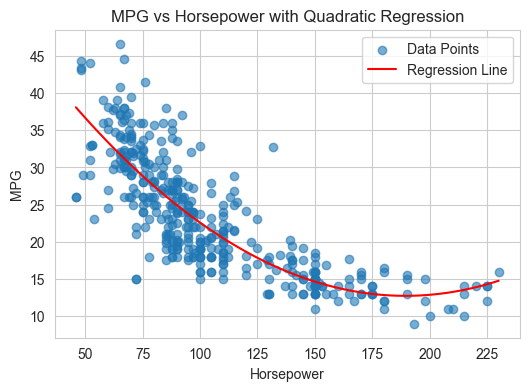

In [97]:
#graph the output of the regression model
# create a grid of horsepower values for plotting the regression line
horsepower_grid = np.linspace(df['horsepower'].min(), df['horsepower'].max
(), 100)
horsepower_grid_squared = horsepower_grid**2
X_grid = pd.DataFrame({'horsepower': horsepower_grid, 'horsepower_squared': horsepower_grid_squared})
X_grid_with_const = sm.add_constant(X_grid)
# predict mpg values using the regression model
mpg_pred = model_weight.predict(X_grid_with_const)
# plot the original data points and the regression line
plt.figure(figsize=(6,4))
plt.scatter(df['horsepower'], df['mpg'], alpha=0.6, label='Data Points')
plt.plot(horsepower_grid, mpg_pred, color='red', label='Regression Line')
plt.xlabel('Horsepower')
plt.ylabel('MPG')
plt.title('MPG vs Horsepower with Quadratic Regression')
plt.legend()
plt.show()



## Make a prediction! ##

In [98]:
print("Predicted MPG for a car with 250 hp:", model_weight.predict([1, 150, 150**2]))

Predicted MPG for a car with 250 hp: [14.65871748]


In [99]:
# add a cubic term to capture even more complex relationship
X = df['horsepower']
X_squared = X**2
X_cubic = X**3
X = pd.DataFrame({'horsepower': X, 'horsepower_squared': X_squared, 'horsepower_cubic': X_cubic })
Y = df['mpg']
X_with_const = sm.add_constant(X)
model_cubic = sm.OLS(Y,X_with_const).fit()
print(model_cubic.summary())



                            OLS Regression Results                            
Dep. Variable:                    mpg   R-squared:                       0.688
Model:                            OLS   Adj. R-squared:                  0.686
Method:                 Least Squares   F-statistic:                     285.5
Date:                Wed, 18 Mar 2026   Prob (F-statistic):           8.41e-98
Time:                        11:43:21   Log-Likelihood:                -1132.8
No. Observations:                 392   AIC:                             2274.
Df Residuals:                     388   BIC:                             2289.
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                         coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------
const                 60.6848      4

### Assessing the cubic model and interpreting the coefficients

The cubic regression model is:

$$
\widehat{mpg} = 60.6848 - 0.5689(\text{horsepower}) + 0.002079(\text{horsepower}^2) - 0.000002147(\text{horsepower}^3)
$$

Model fit:

- $R^2 = 0.6882$
- Adjusted $R^2 = 0.6858$
- F-statistic $= 285.4807$
- Prob(F-statistic) $= 8.41 \times 10^{-98}$

Coefficient output from the cubic model:

- Intercept: coef $= 60.6848$, std err $= 4.5634$, $t = 13.2980$, $p < 0.001$
- Horsepower: coef $= -0.5689$, std err $= 0.1179$, $t = -4.8239$, $p < 0.001$
- Horsepower squared: coef $= 0.002079$, std err $= 0.000948$, $t = 2.1932$, $p = 0.0289$
- Horsepower cubic: coef $= -0.000002147$, std err $= 0.000002378$, $t = -0.9026$, $p = 0.3673$

Interpretation:

- The model explains about **68.8%** of the variation in MPG.
- The linear and squared horsepower terms are statistically significant, so the relationship is not purely linear.
- The cubic term is **not** statistically significant, which means the extra cubic curvature is not strongly supported by the data.
- Overall, horsepower is still a strong predictor of MPG, but the cubic term does not add much beyond the lower-order terms.

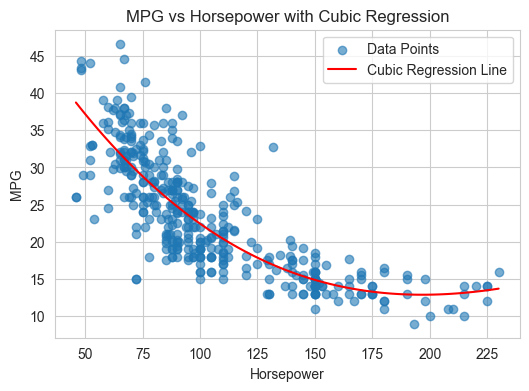

In [100]:
# graph the output of the cubic regression model
horsepower_grid = np.linspace(df['horsepower'].min(), df['horsepower'].max
(), 100)
horsepower_grid_squared = horsepower_grid**2
horsepower_grid_cubic = horsepower_grid**3
X_grid = pd.DataFrame({'horsepower': horsepower_grid, 'horsepower_squared': horsepower_grid_squared, 'horsepower_cubic': horsepower_grid_cubic})
X_grid_with_const = sm.add_constant(X_grid)
mpg_pred_cubic = model_cubic.predict(X_grid_with_const)
plt.figure(figsize=(6,4))
plt.scatter(df['horsepower'], df['mpg'], alpha=0.6, label='Data Points')
plt.plot(horsepower_grid, mpg_pred_cubic, color='red', label='Cubic Regression Line')
plt.xlabel('Horsepower')
plt.ylabel('MPG')
plt.title('MPG vs Horsepower with Cubic Regression')
plt.legend()
plt.show()


## Linear Regression Modelling with MPG as Target Var. & Acceleration as Predictor Variable

In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.model_selection import GridSearchCV
from sklearn.pipeline import Pipeline
import numpy as np

# 1. Pipeline: Polynomial Transform followed by OLS
pipe = Pipeline(steps=[
    ('poly', PolynomialFeatures()),
    ('model', LinearRegression())
])

# 2. Define Parameter Grid (degrees 1-10)
param_grid = {'poly__degree': [1, 2, 3, 4, 5,6,7,8,9,10]}

# 3. Initialize Grid Search
search = GridSearchCV(pipe, param_grid, scoring='neg_mean_squared_error', cv=5)

# 4. Fit to Data
X= df[['horsepower']]
Y = df['mpg']
search.fit(X, Y)

print(search.best_params_)

{'poly__degree': 6}


In [102]:
# run the model with the best degree
best_degree = search.best_params_['poly__degree']
poly = PolynomialFeatures(degree=best_degree)
X_poly = poly.fit_transform(X)
model_final = sm.OLS(Y, X_poly).fit()
print(model_final.summary())

                            OLS Regression Results                            
Dep. Variable:                    mpg   R-squared:                       0.696
Model:                            OLS   Adj. R-squared:                  0.692
Method:                 Least Squares   F-statistic:                     176.6
Date:                Wed, 18 Mar 2026   Prob (F-statistic):           2.13e-97
Time:                        11:43:21   Log-Likelihood:                -1127.9
No. Observations:                 392   AIC:                             2268.
Df Residuals:                     386   BIC:                             2292.
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.1204      0.020      5.999      0.0

*Final Model*

The best performing model based on Mean Square Error was with a power of one through six.



Let's add some new data for high horsepower cars so we don't get that "increase" for higher MPG cars.

Steps:
1) Add new data points
2) Rerun Grid Search with new dataset
3) Examine results

In [103]:
# copy the original dataset but add 20 new rows with horsepower values between 225 and 300
# and mpg values between 7 and 12. Fill the remaining columns with random values
# within the range of the original dataset.

rng = np.random.default_rng(250)
df_augmented = df.copy()

new_rows = pd.DataFrame({
    'mpg': rng.uniform(7, 12, 20),
    'cylinders': rng.choice(sorted(df['cylinders'].unique()), 20),
    'displacement': rng.uniform(df['displacement'].min(), df['displacement'].max(), 20),
    'horsepower': rng.uniform(225, 300, 20),
    'weight': rng.uniform(df['weight'].min(), df['weight'].max(), 20),
    'acceleration': rng.uniform(df['acceleration'].min(), df['acceleration'].max(), 20),
    'model year': rng.integers(df['model year'].min(), df['model year'].max() + 1, 20),
    'origin': rng.choice(sorted(df['origin'].unique()), 20),
    'car name': [f'synthetic_car_{i + 1}' for i in range(20)]
})

new_rows['mpg'] = new_rows['mpg'].round(2)
new_rows['displacement'] = new_rows['displacement'].round(1)
new_rows['horsepower'] = new_rows['horsepower'].round(1)
new_rows['weight'] = new_rows['weight'].round(0).astype(int)
new_rows['acceleration'] = new_rows['acceleration'].round(1)
new_rows['model year'] = new_rows['model year'].astype(int)
new_rows['origin'] = new_rows['origin'].astype(int)

new_rows = new_rows[df.columns]
df_augmented = pd.concat([df_augmented, new_rows], ignore_index=True)

print('Original shape:', df.shape)
print('Augmented shape:', df_augmented.shape)
new_rows.head()

Original shape: (392, 9)
Augmented shape: (412, 9)


,mpg,cylinders,displacement,horsepower,weight,acceleration,model year,origin,car name
0,8.02,5,205.7,293.3,4587,22.4,81,1,synthetic_car_1
1,10.28,3,360.6,240.1,1634,24.0,77,1,synthetic_car_2
2,7.38,5,333.1,251.3,3325,19.7,74,3,synthetic_car_3
3,8.13,3,137.3,251.0,3446,20.1,78,1,synthetic_car_4
4,7.12,8,451.1,279.8,4386,19.1,79,2,synthetic_car_5


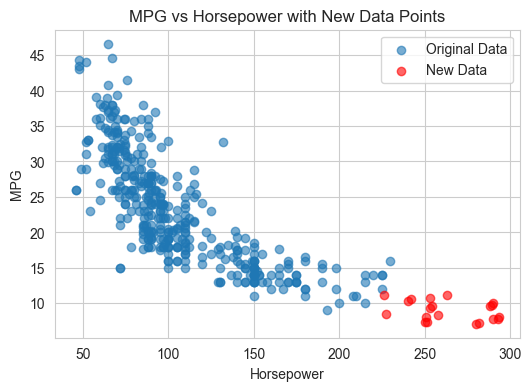

In [104]:
#scatter graph hp vs mpg with the new data points highlighted in a different color
plt.figure(figsize=(6,4))
plt.scatter(df['horsepower'], df['mpg'], alpha=0.6, label='Original Data')
plt.scatter(new_rows['horsepower'], new_rows['mpg'], alpha=0.6, color='red', label='New Data')
plt.xlabel('Horsepower')
plt.ylabel('MPG')
plt.title('MPG vs Horsepower with New Data Points')
plt.legend()
plt.show()


In [105]:
# using our same gridsearch we can run the polynomial regression on the augmented dataset and see if the best degree changes with the new data points
X_augmented = df_augmented[['horsepower']]
Y_augmented = df_augmented['mpg']
search.fit(X_augmented, Y_augmented)
print(search.best_params_)



{'poly__degree': 3}


                            OLS Regression Results                            
Dep. Variable:                    mpg   R-squared:                       0.730
Model:                            OLS   Adj. R-squared:                  0.728
Method:                 Least Squares   F-statistic:                     367.5
Date:                Wed, 18 Mar 2026   Prob (F-statistic):          1.52e-115
Time:                        11:43:21   Log-Likelihood:                -1182.8
No. Observations:                 412   AIC:                             2374.
Df Residuals:                     408   BIC:                             2390.
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         63.2140      3.021     20.927      0.0

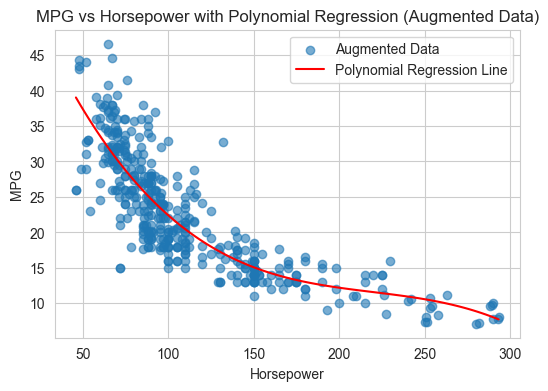

In [106]:
#graph the output of the regression model on the augmented dataset
best_degree = search.best_params_['poly__degree']
poly = PolynomialFeatures(degree=best_degree)
X_poly_augmented = poly.fit_transform(X_augmented)
model_final_augmented = sm.OLS(Y_augmented, X_poly_augmented).fit()
print(model_final_augmented.summary())

horsepower_grid = np.linspace(df_augmented['horsepower'].min(), df_augmented['horsepower'].max(), 100)
horsepower_grid_squared = horsepower_grid**2
horsepower_grid_cubic = horsepower_grid**3
X_grid_augmented = pd.DataFrame({'horsepower': horsepower_grid, 'horsepower_squared': horsepower_grid_squared, 'horsepower_cubic': horsepower_grid_cubic})
X_grid_augmented_with_const = sm.add_constant(X_grid_augmented)
mpg_pred_augmented = model_final_augmented.predict(X_grid_augmented_with_const)
plt.figure(figsize=(6,4))
plt.scatter(df_augmented['horsepower'], df_augmented['mpg'], alpha=0.6, label='Augmented Data')
plt.plot(horsepower_grid, mpg_pred_augmented, color='red', label='Polynomial Regression Line')
plt.xlabel('Horsepower')
plt.ylabel('MPG')
plt.title('MPG vs Horsepower with Polynomial Regression (Augmented Data)')
plt.legend()
plt.show()


In [115]:
# make predictions with the new model on the augmented dataset
print("Predicted MPG for a car with 250 hp (Augmented Model):", model_final_augmented.predict(poly.transform([[250]])))


Predicted MPG for a car with 250 hp (Augmented Model): [10.57708582]


/Users/ericcoopey/anaconda3/envs/dsa250/lib/python3.12/site-packages/sklearn/base.py:465: UserWarning: X does not have valid feature names, but PolynomialFeatures was fitted with feature names
  warnings.warn(


**Selecting the best subset of variables**

This example uses the Auto MPG predictors with `mpg` as the target, excludes `car name`, and one-hot encodes `origin` before fitting the models.

Forward Selection:
Start with no predictors in the model, then add variables one at a time. At each step, choose the variable that produces the highest $R^2$. With plain $R^2$, the score cannot decrease when a variable is added, so the procedure gives an ordered path of variables from most useful early additions to later smaller improvements.

Backward Selection:
Start with all candidate predictors in the model, then remove variables one at a time. At each step, drop the variable whose removal leaves the highest remaining $R^2$. This produces a reverse ranking of which variables can be removed with the smallest loss in fit.

Both methods are greedy procedures, so they provide an interpretable variable ranking and step-by-step model fit path, even though they do not guarantee the globally best subset.

In [107]:
import pandas as pd
import statsmodels.api as sm

selection_df = df.drop(columns=['car name']).copy()
X_selection = selection_df.drop(columns=['mpg']).copy()
Y_selection = selection_df['mpg']
X_selection = pd.get_dummies(X_selection, columns=['origin'], drop_first=True, dtype=int)

candidate_features = list(X_selection.columns)


def fit_subset(feature_list):
    X_subset = sm.add_constant(X_selection[feature_list], has_constant='add')
    fitted_model = sm.OLS(Y_selection, X_subset).fit()
    return fitted_model, fitted_model.rsquared


print('Forward Selection Results')
print('-' * 50)
forward_selected = []
forward_history = []
remaining_features = candidate_features.copy()

step = 1
while remaining_features:
    best_feature = None
    best_score = float('-inf')

    for feature in remaining_features:
        current_features = forward_selected + [feature]
        _, score = fit_subset(current_features)
        if score > best_score:
            best_score = score
            best_feature = feature

    forward_selected.append(best_feature)
    remaining_features.remove(best_feature)
    forward_history.append((step, best_feature, best_score, forward_selected.copy()))
    print(f"Step {step}: added {best_feature:<15} R-squared = {best_score:.4f}")
    step += 1

print('\nFinal forward selection order:')
print(forward_selected)
print(f"Final forward model R-squared = {forward_history[-1][2]:.4f}")
print('Note: with plain R-squared, forward selection keeps improving or stays the same as variables are added.')

print('\nBackward Selection Results')
print('-' * 50)
backward_features = candidate_features.copy()
backward_history = []

full_model, full_score = fit_subset(backward_features)
print(f"Start: all predictors included, R-squared = {full_score:.4f}")

step = 1
while len(backward_features) > 1:
    feature_to_remove = None
    best_score_after_removal = float('-inf')
    best_remaining_set = None

    for feature in backward_features:
        reduced_features = [item for item in backward_features if item != feature]
        _, score = fit_subset(reduced_features)
        if score > best_score_after_removal:
            best_score_after_removal = score
            feature_to_remove = feature
            best_remaining_set = reduced_features

    backward_features = best_remaining_set
    backward_history.append((step, feature_to_remove, best_score_after_removal, backward_features.copy()))
    print(f"Step {step}: removed {feature_to_remove:<15} R-squared = {best_score_after_removal:.4f}")
    step += 1

print('\nFinal backward selection variable(s):')
print(backward_features)
print(f"Final backward model R-squared = {backward_history[-1][2]:.4f}")

print('\nForward path by step:')
for step_number, feature, score, selected_features in forward_history:
    print(f"Step {step_number}: {selected_features} -> R-squared = {score:.4f}")

print('\nBackward path by step:')
for step_number, removed_feature, score, remaining_set in backward_history:
    print(f"Step {step_number}: removed {removed_feature}, remaining {remaining_set} -> R-squared = {score:.4f}")

Forward Selection Results
--------------------------------------------------
Step 1: added weight          R-squared = 0.6926
Step 2: added model year      R-squared = 0.8082
Step 3: added origin_3        R-squared = 0.8122
Step 4: added origin_2        R-squared = 0.8190
Step 5: added displacement    R-squared = 0.8206
Step 6: added horsepower      R-squared = 0.8228
Step 7: added cylinders       R-squared = 0.8239
Step 8: added acceleration    R-squared = 0.8242

Final forward selection order:
['weight', 'model year', 'origin_3', 'origin_2', 'displacement', 'horsepower', 'cylinders', 'acceleration']
Final forward model R-squared = 0.8242
Note: with plain R-squared, forward selection keeps improving or stays the same as variables are added.

Backward Selection Results
--------------------------------------------------
Start: all predictors included, R-squared = 0.8242
Step 1: removed acceleration    R-squared = 0.8239
Step 2: removed cylinders       R-squared = 0.8228
Step 3: removed 

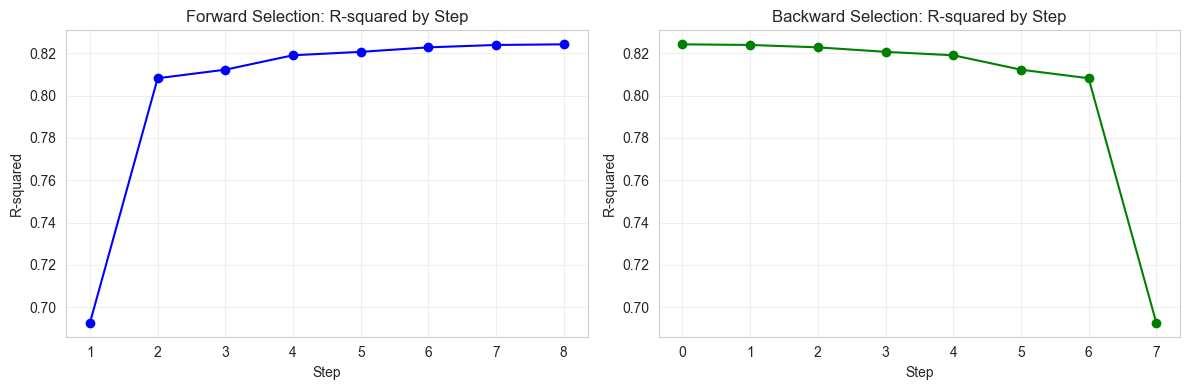

In [108]:
forward_steps = [step_number for step_number, _, _, _ in forward_history]
forward_r2 = [score for _, _, score, _ in forward_history]

backward_steps = [0] + [step_number for step_number, _, _, _ in backward_history]
backward_r2 = [full_score] + [score for _, _, score, _ in backward_history]

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(forward_steps, forward_r2, marker='o', color='blue')
plt.title('Forward Selection: R-squared by Step')
plt.xlabel('Step')
plt.ylabel('R-squared')
plt.xticks(forward_steps)
plt.grid(alpha=0.3)

plt.subplot(1, 2, 2)
plt.plot(backward_steps, backward_r2, marker='o', color='green')
plt.title('Backward Selection: R-squared by Step')
plt.xlabel('Step')
plt.ylabel('R-squared')
plt.xticks(backward_steps)
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

### Why we should not rely on \(R^2\) alone for variable selection

When predictors are added to a regression model, **\(R^2\) can only stay the same or increase**.  
This means a larger model will almost always look better by \(R^2\), even if new variables add very little real value.

Because of that, use the **\(R^2\)-by-step graph** to find a practical cutoff point:
- keep variables while \(R^2\) improves meaningfully,
- stop when the curve starts to flatten (diminishing returns).

So, the cutoff should be based on the point where extra predictors no longer provide a substantial gain in fit.

In [109]:
# select the forward selection model step 4 and show the summary
selected_features = forward_history[3][3]  # Step 4 selected features
X_selected = sm.add_constant(X_selection[selected_features], has_constant='add')
final_model = sm.OLS(Y_selection, X_selected).fit()
print(final_model.summary())


                            OLS Regression Results                            
Dep. Variable:                    mpg   R-squared:                       0.819
Model:                            OLS   Adj. R-squared:                  0.817
Method:                 Least Squares   F-statistic:                     437.9
Date:                Wed, 18 Mar 2026   Prob (F-statistic):          3.53e-142
Time:                        11:43:21   Log-Likelihood:                -1026.1
No. Observations:                 392   AIC:                             2062.
Df Residuals:                     387   BIC:                             2082.
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        -18.3069      4.017     -4.557      0.0

In [110]:
# make a prediction using the final model
new_car = pd.DataFrame({
    'cylinders': [6],
    'displacement': [120],
    'horsepower': [100],
    'weight': [2800],
    'acceleration': [15],
    'model year': [87],
    'origin': [1]
})

# Encode origin against the full training categories so origin = 1, 2, or 3 is handled correctly.
origin_categories = sorted(selection_df['origin'].astype(int).unique())
new_car['origin'] = pd.Categorical(new_car['origin'], categories=origin_categories)
new_car_encoded = pd.get_dummies(new_car, columns=['origin'], drop_first=True, dtype=int)
new_car_encoded = new_car_encoded.reindex(columns=X_selection.columns, fill_value=0)
new_data_with_const = sm.add_constant(new_car_encoded[selected_features], has_constant='add')

predicted_mpg = final_model.predict(new_data_with_const)
print(f"Predicted MPG for the new car: {predicted_mpg.iloc[0]:.2f}")

Predicted MPG for the new car: 32.19


**Play With The Model**

See how changing the inputs changes the outputs.

Notice that if you change variables that aren't in our model (like cylinders), the prediction doesn't change.

In [111]:
new_data_with_const.head()

,const,weight,model year,origin_3,origin_2
0,1.0,2800,87,0,0
